# Data Analysis
**ShipmentSure — Predicting On-Time Delivery**

Cross-dimensional operational comparisons:
- Warehouse vs shipment mode vs rating vs delivery behavior
- Scatter plots, bar plots, and heatmaps for relationship strength

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
print("Libraries loaded.")

Libraries loaded.


In [2]:
df = pd.read_csv('../data/Train.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (1000, 12)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,C,Flight,2,5,306,6,high,M,45,3838,1
1,2,F,Ship,7,2,114,3,high,M,35,2710,1
2,3,B,Ship,7,2,215,7,medium,F,44,4152,0
3,4,A,Road,5,3,126,5,medium,M,54,2245,0
4,5,F,Ship,3,5,113,3,medium,M,43,1806,1


In [3]:
# Average metrics by Warehouse Block
warehouse_analysis = df.groupby('Warehouse_block').mean(numeric_only=True).round(3)
print("Mean values by Warehouse Block:")
warehouse_analysis

Mean values by Warehouse Block:


,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
Warehouse_block,,,,,,,,
A,508.574,4.538,2.970,202.284,6.284,31.462,3379.020,0.569
B,492.539,4.533,2.928,205.344,5.989,30.689,3502.372,0.494
C,539.379,4.734,3.019,197.388,6.028,32.561,3556.977,0.523
D,461.380,4.427,2.873,201.376,5.540,31.117,3530.911,0.474
F,499.760,4.372,3.117,195.765,6.112,34.026,3530.827,0.464


In [4]:
# Pivot table: Mode of Shipment x Warehouse Block x On-Time Rate
pivot = df.pivot_table(
    values='Reached.on.Time_Y.N',
    index='Warehouse_block',
    columns='Mode_of_Shipment',
    aggfunc='mean'
).round(3)
print("On-time rate: Warehouse x Shipment Mode:")
pivot

On-time rate: Warehouse x Shipment Mode:


Mode_of_Shipment,Flight,Road,Ship
Warehouse_block,,,
A,0.462,0.603,0.610
B,0.467,0.569,0.436
C,0.471,0.558,0.536
D,0.449,0.457,0.514
F,0.452,0.414,0.547


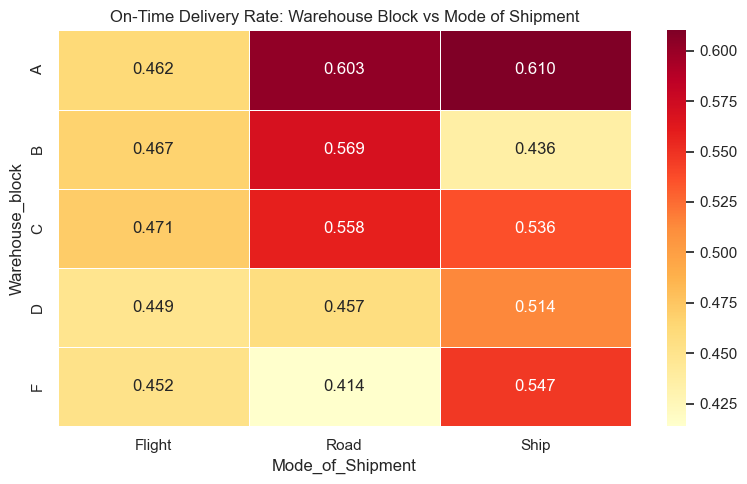

In [5]:
# Heatmap of pivot table
plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, cmap='YlOrRd', fmt='.3f', linewidths=0.5)
plt.title('On-Time Delivery Rate: Warehouse Block vs Mode of Shipment')
plt.tight_layout()
plt.show()

C:\Users\rishi\AppData\Local\Temp\ipykernel_14840\104131516.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=wh_rating.index, y=wh_rating.values, palette='Blues_d')


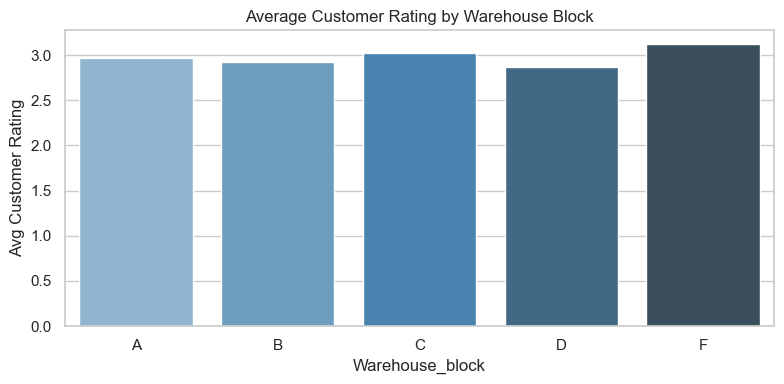

In [6]:
# Bar plot: Average customer rating by warehouse block
plt.figure(figsize=(8, 4))
wh_rating = df.groupby('Warehouse_block')['Customer_rating'].mean()
sns.barplot(x=wh_rating.index, y=wh_rating.values, palette='Blues_d')
plt.title('Average Customer Rating by Warehouse Block')
plt.ylabel('Avg Customer Rating')
plt.tight_layout()
plt.show()

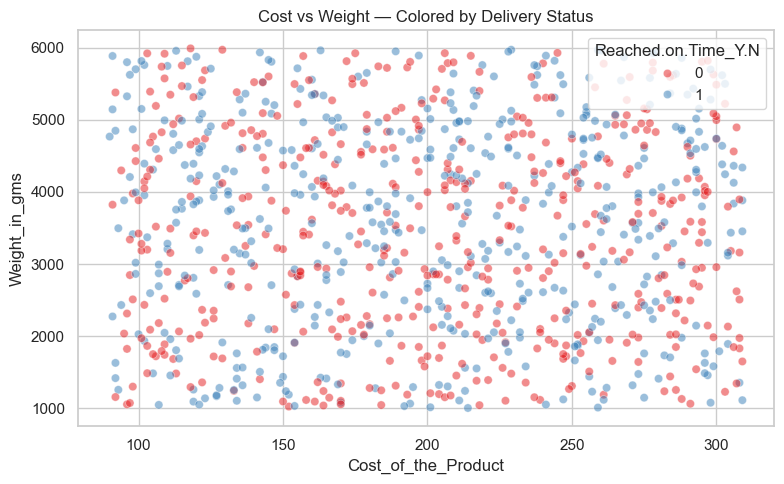

In [7]:
# Scatter: Cost vs Weight colored by on-time delivery
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df, x='Cost_of_the_Product', y='Weight_in_gms',
    hue='Reached.on.Time_Y.N', alpha=0.5, palette='Set1'
)
plt.title('Cost vs Weight — Colored by Delivery Status')
plt.tight_layout()
plt.show()

C:\Users\rishi\AppData\Local\Temp\ipykernel_14840\3803438438.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mode_discount.index, y=mode_discount.values, palette='Greens_d')


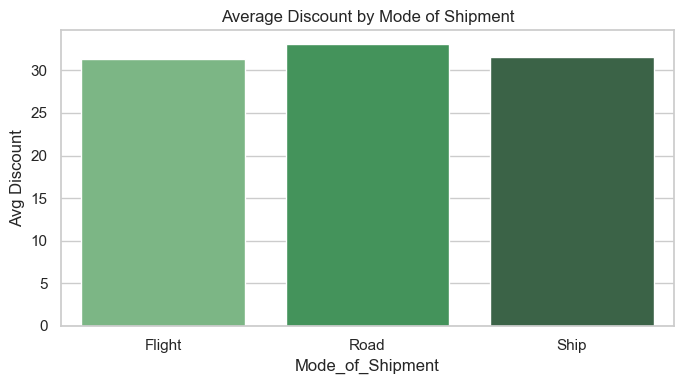

In [8]:
# Bar plot: Avg discount by shipment mode
plt.figure(figsize=(7, 4))
mode_discount = df.groupby('Mode_of_Shipment')['Discount_offered'].mean()
sns.barplot(x=mode_discount.index, y=mode_discount.values, palette='Greens_d')
plt.title('Average Discount by Mode of Shipment')
plt.ylabel('Avg Discount')
plt.tight_layout()
plt.show()

C:\Users\rishi\AppData\Local\Temp\ipykernel_14840\472247948.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Customer_care_calls', y='Reached.on.Time_Y.N', data=call_delivery, palette='Oranges_d')


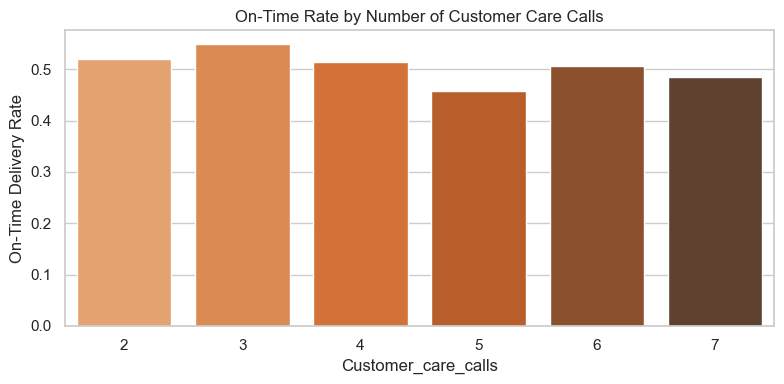

In [9]:
# Customer care calls vs delivery
plt.figure(figsize=(8, 4))
call_delivery = df.groupby('Customer_care_calls')['Reached.on.Time_Y.N'].mean().reset_index()
sns.barplot(x='Customer_care_calls', y='Reached.on.Time_Y.N', data=call_delivery, palette='Oranges_d')
plt.title('On-Time Rate by Number of Customer Care Calls')
plt.ylabel('On-Time Delivery Rate')
plt.tight_layout()
plt.show()